# Discrete-Time Markov Chains for Credit Risk Modeling

---

### Project Overview

This notebook implements a discrete-time Markov Chain (DTMC) model to estimate credit migration and default probabilities on a representative sample of over **7.6 million monthly observations** from **200,000 unique mortgages** (period 2020 - 2025).

### Analysis Goals:

The goal of the analysis is to study the application of the discrete-time stochastic process of Markov chains in credit risk. First, the transition matrix is estimated using maximum likelihood estimation with Laplace smoothing. Next, the assumptions of this model are analyzed and where they fail, and finally, the limitations of the time-homogeneous model are overcome by calibrating the systematic factor $Z_t$ for stress-testing modeling (Basel III), conditioning the transition matrix on the economic cycle.


In [ ]:
# install requirments
# !pip install pandas, numpy, matplotlib, seaborn, scikit-learn, scipy

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader.data as pdr
from scipy.stats import norm
from scipy.optimize import minimize
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({
    'figure.facecolor': "#252525",
    'axes.facecolor' : '#252525', 
    'text.color': 'white',
    'axes.labelcolor':'white',
    'axes.titlecolor' : 'white',
    'xtick.color' : 'white',
    'ytick.color' : 'white',
    'axes.edgecolor' : 'white'
})

## 1. Data Loading and Definition of the State Space

Let $\mathcal{S}$ be a discrete state space. The discrete-time stochastic process $\{ X\}_{n=0}^{\infty}$ in $\mathcal{S}$ is a (first-order) Markov chain if:
$$\mathbb{P}(X_{n+1} = j| X_n=i, X_{n-1} = i_{n-1}, \dots, X_0=i_0) = \mathbb{P}(X_{n+1} = j| X_n=i)$$
$\forall n=0,1,2,\dots$ and for every $i,j \in \textit{S}$


These probabilities can be gathered within the transition matrix, which is defined as a stochastic matrix. In particular, a matrix $\textbf{P} \in \mathbb{R}^{k \times k}$ is called stochastic if $p_{ij} \geq 0$ for every $i,j$ and $\sum_{j \in \mathcal{S}} p_{ij} = 1$



The state space $\mathcal{S}$ is divided as follows:

* **Transient States ($S_T$):**
  * `C`: Current 
  * `D30`: Delinquent 30–59 days
  * `D60`: Delinquent 60–89 days
  * `D90`: Delinquent 90+ days
* **Absorbing States ($S_A$):**
  * `PRE`: Prepaid
  * `DEF`: Default

In [28]:
df = pd.read_csv('sample_svcg_unificato.csv', sep='|')

stati_trans = ['C', 'D30', 'D60', 'D90']
stati_ass = ['PRE', 'DEF']
stati_tot   = stati_trans + stati_ass

# conversione in datetime
df['Date'] = pd.to_datetime(df['PERIOD'].astype(str), format='%Y%m')

print('=== Dataset Analysis ===')
print(f"Total rows: {len(df):,}")
print(f"Unique Mortgages: {df['LOAN_ID'].nunique():,}")
print(f"Period: {df['Date'].min()} - {df['Date'].max()}")

print("\nState Distribution:")
print(df['STATE'].value_counts())

print("\nTransition by year:")
df['Anno'] = df['PERIOD'].astype(str).str[:4]
print(df.groupby('Anno')['LOAN_ID'].nunique())

=== Dataset Analysis ===
Total rows: 7,643,594
Unique Mortgages: 200,000
Period: 2020-01-01 00:00:00 - 2025-09-01 00:00:00

State Distribution:
STATE
C      7500808
D30      54423
PRE      44201
D90      31140
D60      12908
DEF        114
Name: count, dtype: int64

Transition by year:
Anno
2020     45600
2021     93353
2022    133763
2023    177656
2024    174867
2025    163869
Name: LOAN_ID, dtype: int64


---

## Estimating the Transition Matrix

For estimating the transition matrix, the maximum likelihood estimate with Laplace smoothing ($\alpha=1$) is used, which helps regularize the empirical estimate and prevents transitions that are not present in the dataset from being considered zero:

$$p_{ij} = \frac{n_{ij} + \alpha}{\sum_{k=1}^{K} n_{ik} + \alpha \cdot K}$$

where $n_{ij}$ is the number of transitions observed from state $i$ to state $j$, and $K$ is the total number of states.

In [5]:
def laplace(cnt, alpha=1):
    n_i = cnt.sum(axis=1)
    k = len(stati_tot)
    return (cnt + alpha).div(n_i + alpha * k, axis=0)

### 2.1 Identification of Monthly Transitions and Construction of the Count Matrix

For each loan, the monthly transition $t \to t+1$ is extracted, and the count matrix is estimated, applying the absorbing state conditions for the **PRE** and **DEF** states
$$p_{\text{PRE}, \text{PRE}} = 1, \quad p_{\text{DEF}, \text{DEF}} = 1, \quad p_{i,j} = 0 \quad \forall i \in \{\text{PRE}, \text{DEF}\}, i \neq j$$

In [29]:
# calcolo delle transizioni mensili
df['Next State'] = df.groupby('LOAN_ID')['STATE'].shift(-1)
df['Next Date'] = df.groupby('LOAN_ID')['Date'].shift(-1)

df['Data_exp'] = df['Date'] + pd.DateOffset(months=1)
mask = (
    (df['Next Date'] == df['Data_exp']) &
    df['Next State'].notna() &
    (~df['STATE'].isin(['PRE', 'DEF']))
)

trans = df[mask]

# Matrice dei conteggi
conteggi = pd.crosstab(trans['STATE'], trans['Next State'])
conteggi = conteggi.reindex(index = stati_tot, columns=stati_tot, fill_value=0)

# Matrice di transizione
P_matrix = laplace(conteggi)

# Impostiamo PRE e DEF come assorbenti
P_matrix.loc[['PRE', 'DEF'], :] = 0.0
P_matrix.loc['PRE', 'PRE'] = 1.0
P_matrix.loc['DEF', 'DEF'] = 1.0
print(f"Transition Matrix:")
print(P_matrix.to_string(float_format=lambda x: f"{x:.5f}"))



Transition Matrix:
Next State       C     D30     D60     D90     PRE     DEF
STATE                                                     
C          0.98953 0.00458 0.00003 0.00001 0.00585 0.00000
D30        0.45640 0.35959 0.17093 0.00169 0.01128 0.00011
D60        0.17278 0.11441 0.26105 0.44010 0.01150 0.00016
D90        0.11155 0.01105 0.01418 0.84941 0.01095 0.00286
PRE        0.00000 0.00000 0.00000 0.00000 1.00000 0.00000
DEF        0.00000 0.00000 0.00000 0.00000 0.00000 1.00000


In [7]:
P = P_matrix.round(5)
rowsums = P.sum(axis=1)
rowsums

STATE
C      1.0
D30    1.0
D60    1.0
D90    1.0
PRE    1.0
DEF    1.0
dtype: float64

---

## 3. Canonical Form and Analysis of Absorbing Markov Chains

To analyze the long-term properties of the chain (average time before absorption and default/payoff probability), we reorganize the transition matrix $P$ into its **Canonical Form**:

$$P = \begin{bmatrix} \mathbb{Q} & \mathbb{R} \\ \mathbf{0} & I \end{bmatrix}$$

* **$\mathbb{Q} \in \mathbb{R}^{t \times t}$**: Transition matrix between only transient states
* **$\mathbb{R} \in \mathbb{R}^{t \times a}$**: Transition matrix from transient states to absorbing states
* **$\mathbb{I} \in \mathbb{R}^{a \times a}$**: Identity matrix of absorbing states
* **$\mathbf{0} \in \mathbb{R}^{a \times t}$**: Zero matrix

In [8]:
Q_matrix = P_matrix.loc[stati_trans, stati_trans].values
Q = pd.DataFrame(Q_matrix, index=stati_trans, columns=stati_trans)
print(f"Q Matrix:")
print(Q.to_string(float_format = lambda x: f"{x:.4f}"))


R_matrix = P_matrix.loc[stati_trans, stati_ass].values
R = pd.DataFrame(R_matrix, index=stati_trans, columns=stati_ass)
print("\nR Matrix:")
print(R.to_string(float_format = lambda x: f"{x:.4f}"))

Q Matrix:
         C    D30    D60    D90
C   0.9895 0.0046 0.0000 0.0000
D30 0.4564 0.3596 0.1709 0.0017
D60 0.1728 0.1144 0.2611 0.4401
D90 0.1116 0.0110 0.0142 0.8494

R Matrix:
       PRE    DEF
C   0.0058 0.0000
D30 0.0113 0.0001
D60 0.0115 0.0002
D90 0.0109 0.0029


### 3.1 Convergence Checks and Fundamental Matrix $N$

To ensure the existence of the **Fundamental Matrix** $N$, the spectral radius of $Q$ must be strictly less than 1:

$$\rho(Q) = \max_{i} |\lambda_i| < 1$$

If this condition is met, the series $\sum_{k=0}^{\infty} Q^k$ converges and the matrix $(I - Q)$ is invertible:

$$N = (I - Q)^{-1} $$

The elements $n_{ij}$ of the matrix $N$ represent the average number of months a mortgage, starting from transient state $i$, will spend in transient state $j$ before reaching any absorbing state.

In [30]:
eig = np.linalg.eigvals(Q)
raggio_spettrale = max(eig)
print(f"Q's spectral beam: {raggio_spettrale.round(4)}")

Q's spectral beam: 0.994


In [31]:
I =  np.eye(4)
IQ = I - Q
N_matrix = np.linalg.inv(IQ)
N = pd.DataFrame(N_matrix.round(4), index=stati_trans, columns=stati_trans)
print('Fundamental Matrix N:')
print(N.to_string(float_format = lambda x: f"{x:.4f}"))

Fundamental Matrix N:
           C    D30    D60    D90
C   165.6151 1.2584 0.3159 0.9461
D30 158.9544 2.8626 0.7091 2.1128
D60 151.8626 1.5020 1.8087 5.3108
D90 148.6427 1.2836 0.4563 7.9963


---

## 4. Absorbing Transition Matrix and e PD Lifetime

The matrix $B \in \mathbb{R}^{t \times a}$ measures the asymptotic probability ($t \to \infty$) that a loan, starting from a temporary state $i$, ends up in a specific absorbing state $j$:

$$B = N \cdot R = (I - Q)^{-1} R$$

The second column of the matrix $B$, $B_{[\text{DEF}]}$, represents the PD Lifetime not conditioned on time.

In [11]:
B = N @ R
print("B Matrix:")
print(B.to_string(float_format = lambda x: f"{x:.4f}"))

B Matrix:
       PRE    DEF
C   0.9966 0.0034
D30 0.9930 0.0070
D60 0.9838 0.0162
D90 0.9764 0.0236


It can be seen that most of the states in the chain converge to the **PRE** state, while only a small percentage goes to the **DEF** state. Obviously, loans that are in advanced delinquency states have a higher probability of default.

### 4.1 Cumulative Default Probability PD(n)

The cumulative PD is calculated over a finite time horizon of $n$ months. This metric measures the probability that a default will occur by month $n$, starting from any state of the chain.

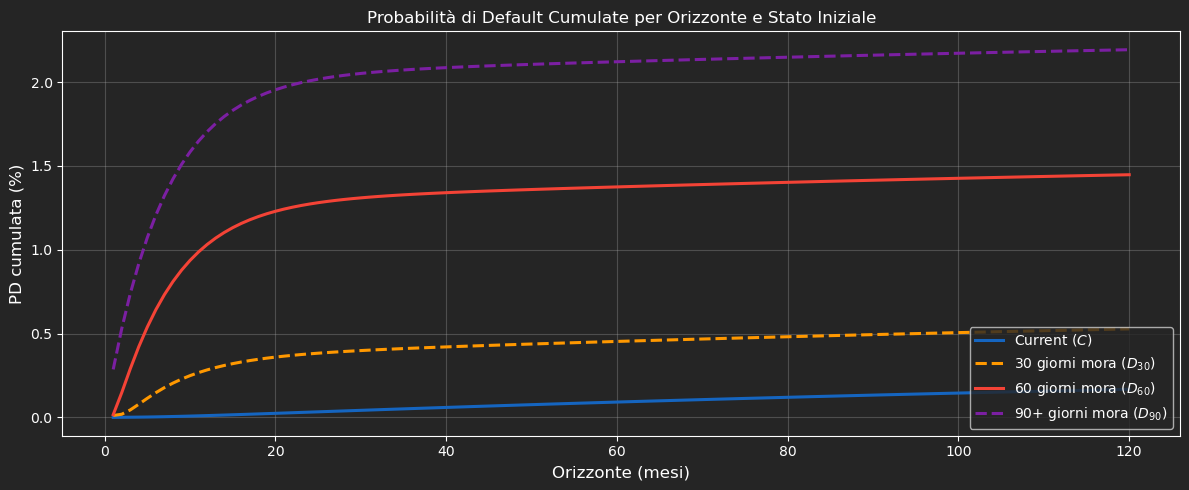

In [23]:
Q_arr = Q.values if isinstance(Q, pd.DataFrame) else Q
R_arr = R.values if isinstance(R, pd.DataFrame) else R
N_arr =  N.values if isinstance(N, pd.DataFrame) else N
B_arr =  B.values if isinstance(B, pd.DataFrame) else B


c, d30, d60, d90 = [], [], [], []
t = range(1, 121)
for n in t:
    Qn = np.linalg.matrix_power(Q_arr, n)
    pd_n = ((I - Qn) @ B_arr)[:, 1]  
    
    c.append(pd_n[0] * 100)
    d30.append(pd_n[1] * 100)
    d60.append(pd_n[2] * 100)
    d90.append(pd_n[3] * 100)

fig, ax = plt.subplots(figsize=(12, 5))

horizons = list(t)

ax.plot(horizons, c,   color='#1565C0', ls='-',  lw=2.2, label=r'Current ($C$)')
ax.plot(horizons, d30, color='#FF9800', ls='--', lw=2.2, label=r'30 giorni mora ($D_{30}$)')
ax.plot(horizons, d60, color='#F44336', ls='-',  lw=2.2, label=r'60 giorni mora ($D_{60}$)')
ax.plot(horizons, d90, color='#7B1FA2', ls='--', lw=2.2, label=r'90+ giorni mora ($D_{90}$)')

ax.set_xlabel('Orizzonte (mesi)', fontsize=12)
ax.set_ylabel('PD cumulata (%)', fontsize=12)
ax.set_title('Probabilità di Default Cumulate per Orizzonte e Stato Iniziale', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
pd_cum = pd.DataFrame({
    'c' : c,
    'D30' : d30,
    'D60' : d60,
    'D90' : d90
})

pd_cum_final = pd_cum.iloc[-1]
print("=== Final cumulative default probabilities ===")
print(pd_cum_final.to_string(float_format = lambda x : f"{x :.4f}"))

=== Final cumulative default probabilities ===
c     0.1676
D30   0.5277
D60   1.4475
D90   2.1931


---

## 5. Portfolio Dynamics Simulation

We project the composition of a mortgage portfolio over a 120-month (10-year) horizon, given the estimated empirical transition matrix.

Given an initial position distribution vector $\boldsymbol{\pi}_0$:

$$\boldsymbol{\pi}_0 = \begin{bmatrix} 80\% & 15\% & 2.5\% & 2.5\% & 0\% & 0\% \end{bmatrix}$$

corresponding respectively to the states `[C, D30, D60, D90, PRE, DEF]`, the portfolio distribution at month $n$ is given by the evolution:

$$\boldsymbol{\pi}_n = \boldsymbol{\pi}_0 \cdot P^n$$

where $P^n$ represents the transition matrix raised to the $n$-th power.

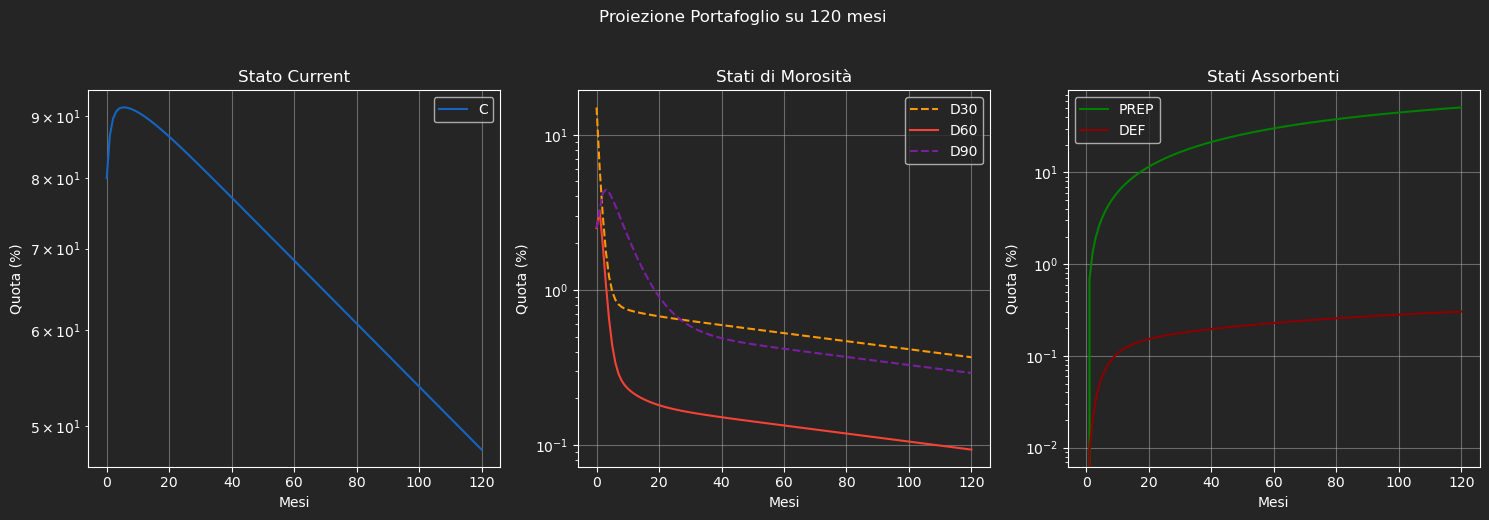

In [24]:
pi_0 = [0.80, 0.15, 0.025, 0.025, 0, 0]

# Valori Cumulati
s1, s2, s3, s4, s5, s6 = [], [], [], [], [], []

for i in range(121):
    Pn = np.linalg.matrix_power(P_matrix, i)
    pi_n = pi_0 @ Pn

    s1.append(pi_n[0] * 100)
    s2.append(pi_n[1] * 100)
    s3.append(pi_n[2] * 100)
    s4.append(pi_n[3] * 100)
    s5.append(pi_n[4] * 100)
    s6.append(pi_n[5] * 100)

t = list(range(121))


# Plot
plt.close('all')
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(t, s1, label='C', color='#1565C0', linestyle='-')
ax[0].set_yscale('log')
ax[0].set_title('Stato Current')
ax[0].set_xlabel('Mesi')
ax[0].set_ylabel('Quota (%)')
ax[0].grid(alpha=.5)
ax[0].legend()

ax[1].plot(t, s2, label='D30', color='#FF9800', linestyle = '--')
ax[1].plot(t, s3, label='D60', color='#F44336', linestyle = '-')
ax[1].plot(t, s4, label='D90', color='#7B1FA2', linestyle = '--')
ax[1].set_yscale('log')
ax[1].set_title('Stati di Morosità')
ax[1].set_xlabel('Mesi')
ax[1].set_ylabel('Quota (%)')
ax[1].grid(alpha=.5)
ax[1].legend()

ax[2].plot(t, s5, label='PREP', color='green')
ax[2].plot(t, s6, label='DEF', color='darkred')
ax[2].set_yscale('log')
ax[2].set_title('Stati Assorbenti')
ax[2].set_xlabel('Mesi')
ax[2].set_ylabel('Quota (%)')
ax[2].grid(alpha=.5)

plt.legend()
plt.suptitle('Proiezione Portafoglio su 120 mesi ', fontsize=12, y=1.03)
plt.subplots_adjust()
plt.tight_layout()
plt.show()

In the very short term (first 5-10 months), the share in the Current status rises from 80% to over 90%. This is probably due to previously delinquent accounts returning to good standing. On the other hand, delinquency states show an exponential drop in the first 20 months, then stabilize on a more gradual declining trend in the long run.

Over this time frame, most of the portfolio moves toward the Prepayment status, while the accumulated Default share remains significantly low.

---

## 6. Issues with the Homogeneous Model: Checking Temporal Stationarity

The basic assumption of time-homogeneous Markov chains is that the transition probabilities are constant over time:

$$P(X_{t+1} = j \mid X_t = i) = p_{ij}, \quad \forall t$$

To verify the empirical validity of this assumption, we estimate the annual transition matrices $P^{(y)}$ for each year $y \in [2020, 2025]$ using the maximum likelihood estimator with Laplace smoothing:

$$\hat{p}_{ij}^{(y)} = \frac{n_{ij}^{(y)} + \alpha}{\sum_{k} n_{ik}^{(y)} + K \cdot \alpha}$$

And let's see whether they are constant over time or not.

We'll isolate the time dynamics of the most relevant transitions to assess the impact of the economic cycle and macroeconomic/regulatory interventions:

* **Cure Rate (`D30 -> C`):** 
* **Entry Rate (`C -> D30`):** 
* **Roll Rate (`D30 -> D60`):** 
* **Persistence (`D90 -> D90`):** 

In [18]:
anni = sorted(df['Date'].dt.year.unique())

matrici_annuali = []
for anno in anni:
    trans_anno = df[df['Date'].dt.year == anno]

    cnt = pd.crosstab(index=trans_anno['STATE'], columns=trans_anno['Next State'])
    cnt = cnt.reindex(index=stati_trans, columns=stati_tot, fill_value=0)
    P_anno = laplace(cnt)
    matrici_annuali.append(P_anno)

P_2020 = matrici_annuali[0]
P_2021 = matrici_annuali[1]
P_2022 = matrici_annuali[2]
P_2023 = matrici_annuali[3]
P_2024 = matrici_annuali[4]
P_2025 = matrici_annuali[5]


anni_storici = [2020, 2021, 2022, 2023, 2024, 2025]

dati = pd.DataFrame({
    'D30 -> C':   [matrici_annuali[i].loc['D30', 'C'] * 100 for i in range(len(anni_storici))],
    'C -> D30':   [matrici_annuali[i].loc['C', 'D30'] * 100 for i in range(len(anni_storici))],
    'D30 -> D60': [matrici_annuali[i].loc['D30', 'D60'] * 100 for i in range(len(anni_storici))],
    'D90 -> D90': [matrici_annuali[i].loc['D90', 'D90'] * 100 for i in range(len(anni_storici))],
}, index=anni_storici)


print(dati.to_string(float_format = lambda x: f"{x:.4f}"))

      D30 -> C  C -> D30  D30 -> D60  D90 -> D90
2020   45.2720    0.5823     39.4430     87.3079
2021   61.8260    0.3084     18.1165     87.2032
2022   58.6011    0.3904     14.6975     83.2346
2023   48.7919    0.4434     15.7308     85.4393
2024   42.0894    0.5169     16.8815     84.4998
2025   37.5281    0.5235     16.9049     84.1666


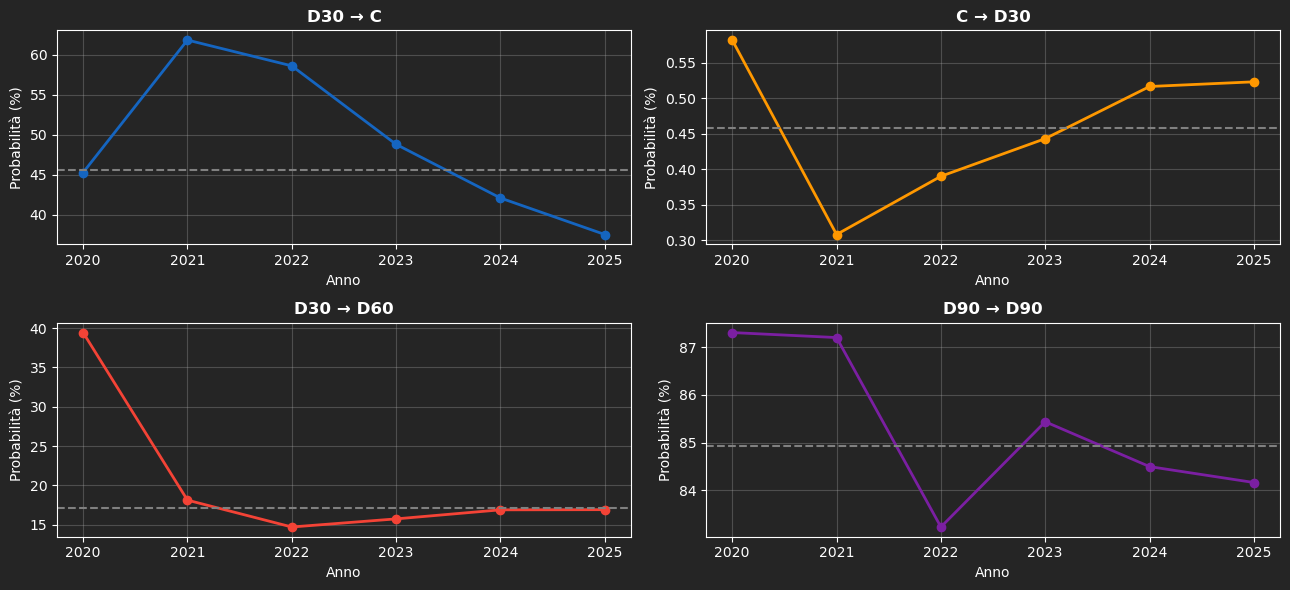

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

# D30 -> C
axes[0, 0].plot(dati['D30 -> C'], marker='o', color='#1565C0', lw=2)
axes[0, 0].axhline(P_matrix.loc['D30', 'C'] * 100, color='grey', linestyle='--')
axes[0, 0].set_title('D30 → C', fontweight='bold')
axes[0, 0].set_ylabel('Probabilità (%)')
axes[0, 0].set_xlabel('Anno')
axes[0, 0].set_xticks(dati.index)
axes[0, 0].grid(alpha=0.3)

# C -> D30
axes[0, 1].plot(dati['C -> D30'], marker='o', color='#FF9800', lw=2)
axes[0, 1].axhline(P_matrix.loc['C', 'D30'] * 100, color='grey', linestyle='--')
axes[0, 1].set_title('C → D30', fontweight='bold')
axes[0, 1].set_ylabel('Probabilità (%)')
axes[0, 1].set_xlabel('Anno')
axes[0, 1].set_xticks(dati.index)
axes[0, 1].grid(alpha=0.3)

# D30 -> D60
axes[1, 0].plot(dati['D30 -> D60'], marker='o', color='#F44336', lw=2)
axes[1, 0].axhline(P_matrix.loc['D30', 'D60'] * 100, color='grey', linestyle='--')
axes[1, 0].set_title('D30 → D60', fontweight='bold')
axes[1, 0].set_ylabel('Probabilità (%)')
axes[1, 0].set_xlabel('Anno')
axes[1, 0].set_xticks(dati.index)
axes[1, 0].grid(alpha=0.3)

# D90 -> D90
axes[1, 1].plot(dati['D90 -> D90'], marker='o', color='#7B1FA2', lw=2)
axes[1, 1].axhline(P_matrix.loc['D90', 'D90'] * 100, color='grey', linestyle='--')
axes[1, 1].set_title('D90 → D90', fontweight='bold')
axes[1, 1].set_ylabel('Probabilità (%)')
axes[1, 1].set_xlabel('Anno')
axes[1, 1].set_xticks(dati.index)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6.1 Time-Varying Estimate

To understand the effect of time discretization, we compare the Roll Rate for the transitions $D60 \rightarrow D90$ and $D60 \rightarrow D30$ and the Cure Rate, that is, the transition $D30 \rightarrow C$, through 3 perspectives:

1. **True $p(t)$:** High-frequency monthly estimate $p_{D60 \rightarrow D90}(t)$, sensitive to short-term noise and seasonality.
2. **Time-Varying Estimate:** Estimate calculated on an annual basis, capturing the medium-term trend by smoothing out the monthly noise component.
3. **Homogeneous Estimate:** Constant unconditional historical average $\bar{p}$, assumed by the standard time-homogeneous model.

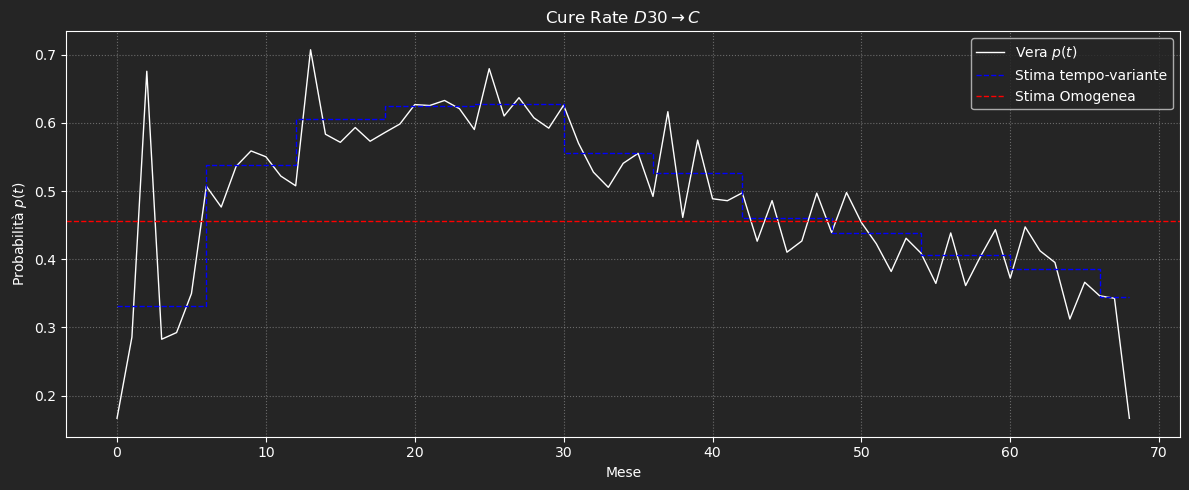

In [26]:
df["Mese"] = df["Date"].dt.to_period("M")
df["Semestre"] = df["Date"].dt.year.astype(str) + np.where(df["Date"].dt.month <= 6, "-S1", "-S2")

mesi = sorted(df["Mese"].unique())
stato_iniziale = 'D30'
stato_finale = 'C'

p_true_m = []
p_blocchi_semestrali = []
p_omogeneo = P_matrix.loc[stato_iniziale, stato_finale]

matrici_sem = {}


for m in mesi:
    # Probabilita mensile vera
    data_m = df[df["Mese"] == m]
    cnt_m = pd.crosstab(index=data_m["STATE"], columns=data_m["Next State"])
    cnt_m = cnt_m.reindex(index=stati_trans, columns=stati_tot, fill_value=0)

    P_m = laplace(cnt_m)
    p_true_m.append(P_m.loc[stato_iniziale, stato_finale]) 

    #  Matrice Semestrale 
    sem_id = f"{m.year}-S{1 if m.month <= 6 else 2}"
    if sem_id not in matrici_sem:
        data_sem = df[df["Semestre"] == sem_id]
        cnt_sem = pd.crosstab(index=data_sem["STATE"], columns=data_sem["Next State"])
        cnt_sem = cnt_sem.reindex(index=stati_trans, columns=stati_tot, fill_value=0)
        matrici_sem[sem_id] = laplace(cnt_sem)

    p_blocchi_semestrali.append(matrici_sem[sem_id].loc[stato_iniziale, stato_finale])

# Plot
plt.figure(figsize=(12, 5))
x = np.arange(len(mesi))


plt.plot(x, p_true_m, color="white", linewidth=1, label="Vera $p(t)$")
plt.plot(x, p_blocchi_semestrali, color="blue", linestyle="--", drawstyle="steps-post", label="Stima tempo-variante", linewidth=1,)
plt.axhline(p_omogeneo, linestyle="--", color="red", linewidth=1, label="Stima Omogenea",)

plt.title(f"Cure Rate ${stato_iniziale} \\rightarrow {stato_finale}$")
plt.xlabel("Mese")
plt.ylabel("Probabilità $p(t)$")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

The figure above, which shows the trend of the Cure Rate over the time horizon, highlights a marked non-stationarity of the empirical probability, shown in black. The homogeneous estimate remains consistently around 45%, while the time-varying estimate, built through continuous recalibration of the transition matrix every six months, manages to follow the actual probability while avoiding short-term noise. Moreover, the homogeneous estimate has strong fundamental implications: in fact, it underestimates the real probability of returning to good standing in the first half of the observed time horizon, where the probability is around 60%, and overestimates it in the subsequent period, where the rate of returning to good standing steadily declines to 25%.

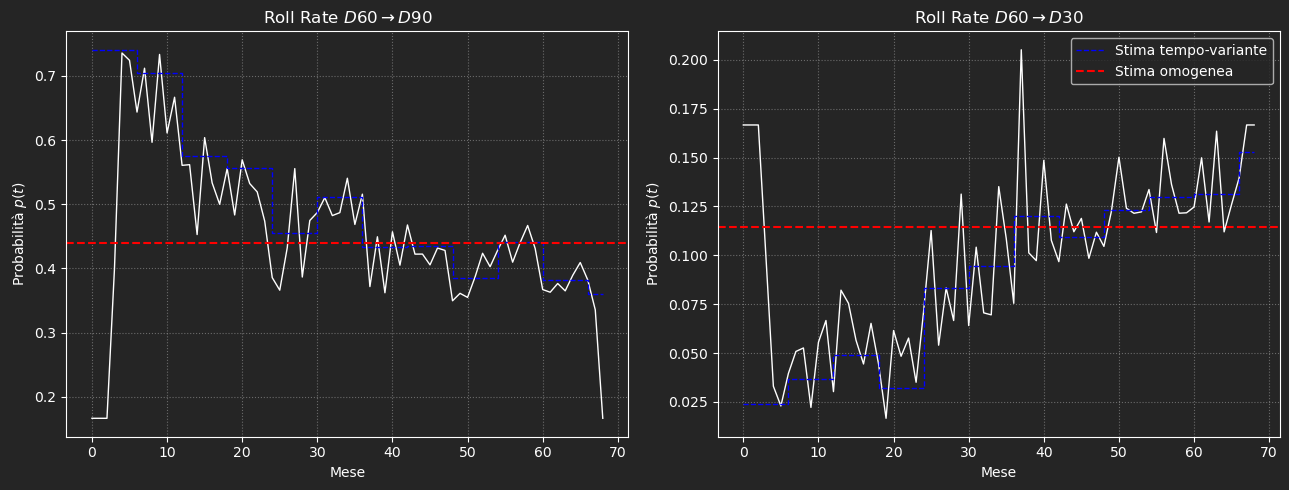

In [27]:
df["Mese"] = df["Date"].dt.to_period("M")
df["Semestre"] = df["Date"].dt.year.astype(str) + np.where(df["Date"].dt.month <= 6, "-S1", "-S2")

mesi = sorted(df["Mese"].unique())
stato_iniziale_1 = 'D60'
stato_finale_1 = 'D90'

stato_iniziale_2 = 'D60'
stato_finale_2 = 'D30'


p_true_m_1 = []
p_true_m_2 = []

p_blocchi_semestrali_1 = []
p_blocchi_semestrali_2 = []

p_omogeneo_1 = P_matrix.loc[stato_iniziale_1, stato_finale_1]
P_omogeneo_2 = P_matrix.loc[stato_iniziale_2, stato_finale_2]

matrici_sem = {}


for m in mesi:
    # Probabilita mensile vera
    data_m = df[df["Mese"] == m]
    cnt_m = pd.crosstab(index=data_m["STATE"], columns=data_m["Next State"])
    cnt_m = cnt_m.reindex(index=stati_trans, columns=stati_tot, fill_value=0)

    P_m = laplace(cnt_m)
    p_true_m_1.append(P_m.loc[stato_iniziale_1, stato_finale_1]) 
    p_true_m_2.append(P_m.loc[stato_iniziale_2, stato_finale_2])

    #  Matrice Semestrale 
    sem_id = f"{m.year}-S{1 if m.month <= 6 else 2}"
    if sem_id not in matrici_sem:
        data_sem = df[df["Semestre"] == sem_id]
        cnt_sem = pd.crosstab(index=data_sem["STATE"], columns=data_sem["Next State"])
        cnt_sem = cnt_sem.reindex(index=stati_trans, columns=stati_tot, fill_value=0)
        matrici_sem[sem_id] = laplace(cnt_sem)

    p_blocchi_semestrali_1.append(matrici_sem[sem_id].loc[stato_iniziale_1, stato_finale_1])
    p_blocchi_semestrali_2.append(matrici_sem[sem_id].loc[stato_iniziale_2, stato_finale_2])


# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(mesi))

ax1.plot(x, p_true_m_1, color='white', linewidth=1)
ax1.plot(x, p_blocchi_semestrali_1, color="blue", linestyle="--", drawstyle="steps-post", label="Stima tempo-variante", linewidth=1,)
ax1.axhline(p_omogeneo_1, color='red', linestyle='--', label='Stima omogenea')
ax1.set_title(f"Roll Rate ${stato_iniziale_1} \\rightarrow {stato_finale_1}$")
ax1.set_xlabel("Mese")
ax1.set_ylabel("Probabilità $p(t)$")
ax1.grid(True, linestyle=":", alpha=0.5)


ax2.plot(x, p_true_m_2, color='white', linewidth=1)
ax2.plot(x, p_blocchi_semestrali_2, color='blue', linestyle='--', drawstyle='steps-post', label='Stima tempo-variante', linewidth=1)
ax2.axhline(P_omogeneo_2, color='red', linestyle='--', label='Stima omogenea')
ax2.set_title(f"Roll Rate ${stato_iniziale_2} \\rightarrow {stato_finale_2}$")
ax2.set_xlabel("Mese")
ax2.set_ylabel("Probabilità $p(t)$")
ax2.grid(True, linestyle=":", alpha=0.5)


plt.legend()
plt.tight_layout()
plt.show()

The two Roll Rates also highlight the same non-stationarity of the empirical probability. Looking at the transition to higher delinquency states ($D_{60} 
\rightarrow D_{90}$), you can see that in the first 12 months the actual deterioration rate hits peaks above 70%. The homogeneous estimate, around 44%, doesn't reflect this high-risk phase at all, leading to a substantial underestimation of provisions for expected losses.

# First-Order Markov Property

The first-order Markov property assumes that the current state of the loan summarizes all the relevant information needed to predict its future evolution. In other words, two loans that are currently in $D_{30}$ should have the same future distribution, regardless of how they got there. If this property held, the cure rate of a loan in $D_{30}$ shouldn't depend on its previous state. However, it's reasonable to expect that a loan that ended up in $D_{30}$ from $C$ would have a higher cure rate than a loan that came from $D_{60}$ (a loan that is coming from a more severe delinquency, with structural issues).

In [33]:
new_df = df.copy()
new_df = new_df.sort_values(by=['LOAN_ID', 'Date'])
new_df['Prev State'] = new_df.groupby('LOAN_ID')['STATE'].shift(1)

df_d30c = new_df[
    (new_df['STATE'] == 'D30') &
    (new_df['Prev State'].isin(['C'])) &
    (new_df['Next State'].notna())
]

df_d30c = df_d30c[['LOAN_ID', 'Prev State', 'STATE', 'Next State', 'Date', 'Next Date']]

df_d30d60 = new_df[
    (new_df['STATE'] == 'D30') &
    (new_df['Prev State'] == 'D60') &
    (new_df['Next State'].notna())
]
df_d30d60 = df_d30d60[['LOAN_ID', 'Prev State', 'STATE', 'Next State', 'Date', 'Next Date']]

tabella_transizioni_c = pd.crosstab(df_d30c['STATE'],  df_d30c['Next State'],  normalize='index') * 100
tabella_transizioni_d60 = pd.crosstab(df_d30d60['STATE'], df_d30d60['Next State'], normalize='index') * 100

print("=== D30 Transitions (Previous state C) ===")
print(tabella_transizioni_c.round(2))

print("\n === D30 Transitions (Previous state D60) ===")
print(tabella_transizioni_d60.round(2))

=== D30 Transitions (Previous state C) ===
Next State      C    D30    D60   D90   DEF   PRE
STATE                                            
D30         56.69  24.34  17.43  0.06  0.01  1.47

 === D30 Transitions (Previous state D60) ===
Next State     C    D30    D60   D90   PRE
STATE                                     
D30         21.7  43.26  33.26  1.33  0.44


As highlighted by these results, the hypothesis of no memory is clearly contradicted by the empirical data from the portfolio.

Regarding the rate of returning to good standing, for loans that reached $D_{30}$ from the Current state, the probability of recovery in the following month is 56.69%. In contrast, for loans that reached $D_{30}$ from the $D_{60}$ state, this probability drops to 21.70%.
Similarly, loans coming from $D_{60}$ tend to stay in delinquency or deteriorate further, showing a 43.26% chance of staying in $D_{30}$ and a 33.26% chance of worsening to $D_{60}$, compared to 17.44% observed for those coming from Current.

---

## 6.2 Macroeconomic Conditioning of the Transition Matrix

Before getting to the macroeconomic conditioning of the transition matrix, let's look at how, by dividing the data based on macroeconomic variables, we can see changes in the probability estimates. So first, we can split the dataset according to the economic cycle, choosing unemployment as the variable that represents it.

What we'll implement is therefore a division of the dataset based on the trend of the U.S. unemployment rate, calculating the respective transition matrices, where we expect to observe some discrepancies.

In [36]:
# dati unemployment
un = pdr.DataReader('UNRATE', 'fred', start='2020-01-01', end='2025-12-01')

df_un = df.merge(un, left_on='Date', right_index=True, how='left')
df_un['UNRATE'] = df['Date'].map(un['UNRATE'])

df_un = df_un[['Date', 'Next Date', 'LOAN_ID', 'STATE', 'Next State', 'UNRATE', 'Anno']]

for classifying the cycle based on unemployment we use a Z_score:
$$\text{Z-score} = \frac{Unrate_T - \mu}{\sigma}$$


Data for P_good estimated: 6,918,789 rows
Data for P_bad estimated: 724,805 rows


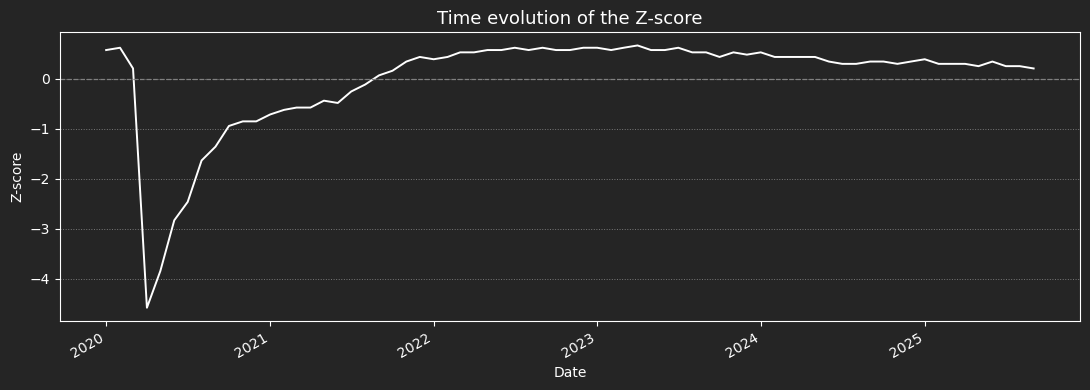

In [38]:
mu = un['UNRATE'].mean()
sigma = un['UNRATE'].std()

df_un['Z_score'] = - (df_un['UNRATE'] - mu) / sigma

# suddivisione per ciclo
df_good = df_un[df_un['Z_score'] > 0]
df_bad = df_un[df_un['Z_score'] < 0]

# stima delle matrici macroeconomiche per ciclo economico
stati_tot = ['C', 'D30', 'D60', 'D90', 'DEF', 'PRE']

P_good = pd.crosstab(df_good['STATE'], df_good['Next State'])
P_good = P_good.reindex(index=stati_tot, columns=stati_tot, fill_value=0)
P_good = laplace(P_good)

# stati assorbenti
P_good.loc[['PRE', 'DEF'], :] = 0.0
P_good.loc['PRE', 'PRE'] = 1.0
P_good.loc['DEF', 'DEF'] = 1.0



P_bad = pd.crosstab(df_bad['STATE'], df_bad['Next State'])
P_bad = P_bad.reindex(index=stati_tot, columns=stati_tot, fill_value=0)
P_bad = laplace(P_bad)

P_bad.loc[['PRE', 'DEF'], :] = 0.0
P_bad.loc['PRE', 'PRE'] = 1.0
P_bad.loc['DEF', 'DEF'] = 1.0


print(f"Data for P_good estimated: {len(df_good):,} rows")
print(f"Data for P_bad estimated: {len(df_bad):,} rows")


# plot Z-score
z_score_mensile = (df_un[['Date', 'Z_score']].drop_duplicates().sort_values('Date'))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(z_score_mensile['Date'], z_score_mensile['Z_score'], color='white', linewidth=1.4)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.9)

ax.set_title('Time evolution of the Z-score', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Z-score')
ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

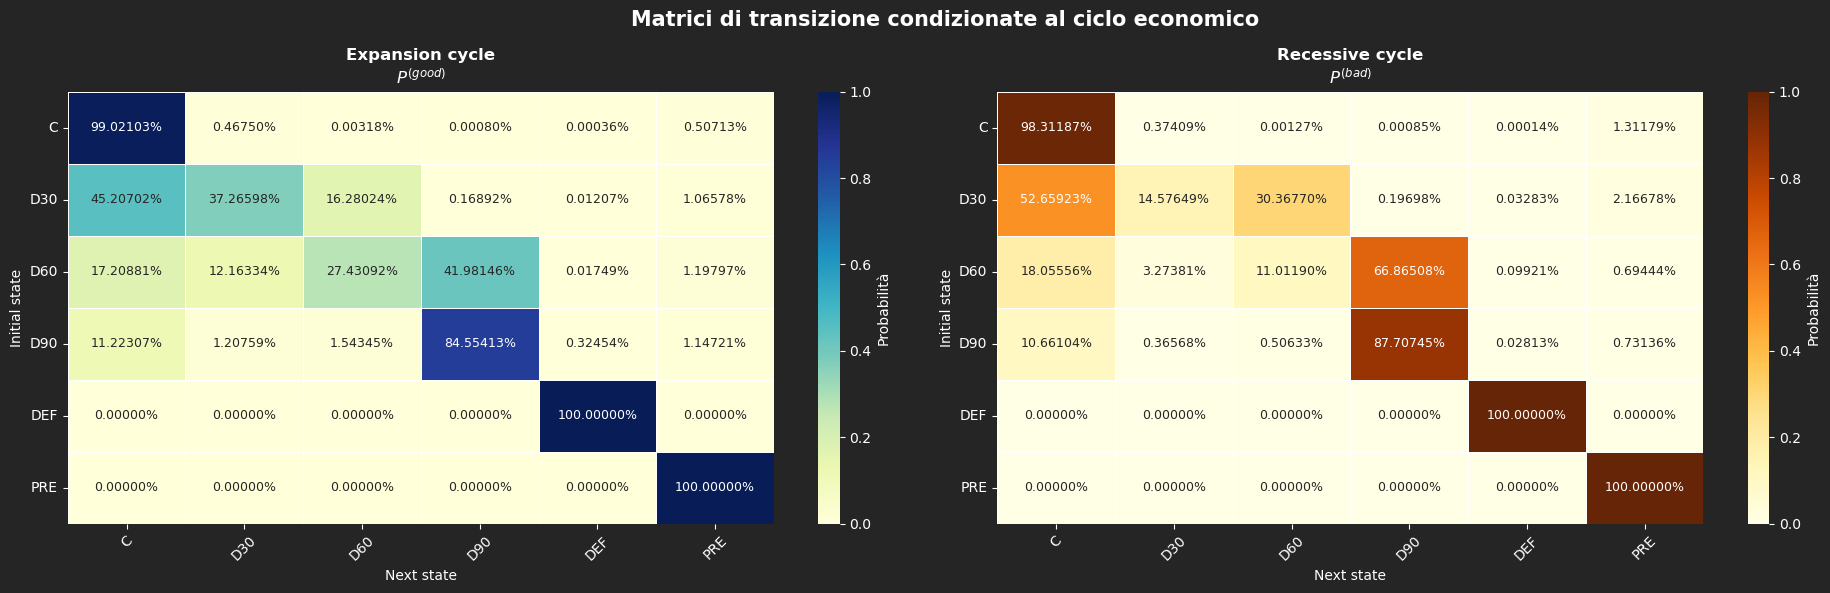

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(19, 6))

sns.heatmap(P_good, ax=axes[0], cmap='YlGnBu', vmin=0, vmax=1, annot=True, fmt='.5%', annot_kws={'fontsize': 9}, linewidths=0.5, linecolor='white', cbar_kws={'label': 'Probabilità'})
axes[0].set_title('Expansion cycle\n$P^{(good)}$', fontweight='bold')
axes[0].set_xlabel('Next state')
axes[0].set_ylabel('Initial state')

sns.heatmap(P_bad, ax=axes[1], cmap='YlOrBr', vmin=0, vmax=1, annot=True, fmt='.5%', annot_kws={'fontsize': 9}, linewidths=0.5, linecolor='white', cbar_kws={'label': 'Probabilità'})
axes[1].set_title('Recessive cycle\n$P^{(bad)}$', fontweight='bold')
axes[1].set_xlabel('Next state')
axes[1].set_ylabel('Initial state')


for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle(
    'Matrici di transizione condizionate al ciclo economico',
    fontsize=15,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

# Analisi dei coefficienti di variazione

The volatility of the parameters is examined by calculating the coefficient of variation for each cell, both for the conditional matrices and for the unconditional matrix. The coefficient of variation is calculated as:
$$CV_{ij} = \frac{\sigma_{ij}}{\mu_{ij}}$$
Where $\mu_{ij}$ represents the average transition probability from state $i$ to state $j$, calculated over the historical series of annual matrices
$$\mu_{ij} = \frac{1}{T} \sum_{t=1}^T p_{ij}^{(t)}$$
While $\sigma_{i,j}$  represents the sample standard deviation for the same cell
$$\sigma_{ij} = \sqrt{\frac{1}{T-1} \sum_{t=1}^{T} \left( p_{ij}^{(t)} - \mu_{,j} \right)^2}$$

The Coefficient of Variation serves as an index of relative variability: high values indicate a high instability of the estimated probability, while a low value indicates a structurally stable transition over time.

In [40]:
lista_matrici = list(matrici_annuali)
blocco_matrici = pd.concat(lista_matrici)

mu = blocco_matrici.groupby(blocco_matrici.index).mean()
sigma = blocco_matrici.groupby(blocco_matrici.index).std()

cv = (sigma/mu) * 100

print("Coefficient of Variation (CV) for initial state (Homogeneous Matrix):")
print("")
print(cv.to_string(float_format=lambda x: f"{x:.3f}"))

Coefficient of Variation (CV) for initial state (Homogeneous Matrix):

Next State      C    D30    D60    D90    PRE    DEF
STATE                                               
C           0.401 21.774 55.982 52.042 52.475 85.103
D30        19.353 42.426 46.571 53.999 38.838 79.943
D60        18.439 51.056 41.749 25.574 33.033 68.708
D90        10.583 49.160 49.904  1.952 24.839 99.255


In [41]:
matrici_bad_annuali = []

for anno in df_bad['Anno'].unique():
    new_df = df_bad[df_bad['Anno'] == anno]
    P_t = pd.crosstab(new_df['STATE'], new_df['Next State'])
    P_t = P_t.reindex(index=stati_trans, columns=stati_tot, fill_value=0)
    P_t = laplace(P_t)
    
    matrici_bad_annuali.append(P_t)

blocco_bad = pd.concat(matrici_bad_annuali)
mu_bad = blocco_bad.groupby(blocco_bad.index).mean()
std_bad = blocco_bad.groupby(blocco_bad.index).std()

cv_bad = (std_bad / mu_bad) * 100
cv_bad = cv_bad.fillna(0)

print("Coefficient of Variation (CV) for initial state (P_bad):")
print("")
print(cv_bad.to_string(float_format=lambda x: f"{x:.3f}"))

Coefficient of Variation (CV) for initial state (P_bad):

Next State      C    D30    D60    D90    DEF    PRE
STATE                                               
C           0.130 39.500 42.820 91.549 42.820  2.730
D30        21.379 13.016 44.545 61.664  1.297 26.189
D60        23.415 22.083 44.267 16.928 30.125 62.170
D90         0.956 41.771 43.748  0.390 22.518 26.003


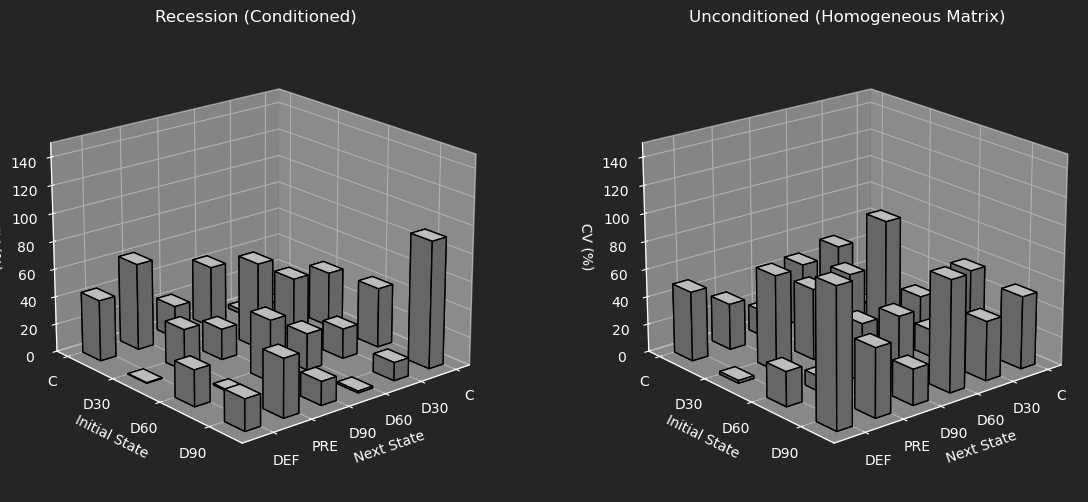

In [42]:
stati_ordinati = ['C', 'D30', 'D60', 'D90', 'PRE', 'DEF']
cv_bad = cv_bad.reindex(columns=stati_ordinati).fillna(0)
cv = cv.reindex(columns=stati_ordinati).fillna(0)

righe = len(cv.index)       
colonne = len(cv.columns)   
x, y = np.meshgrid(range(colonne), range(righe), indexing='ij')

fig = plt.figure(figsize=(14, 6))

# condizionato
ax1 = fig.add_subplot(121, projection='3d')
ax1.bar3d(x.ravel(), y.ravel(), 0, 0.4, 0.4, cv_bad.values.ravel(), color='whitesmoke', edgecolor='black')

ax1.set_xticks(range(colonne))
ax1.set_xticklabels(cv_bad.columns)
ax1.set_yticks(range(righe))
ax1.set_yticklabels(cv_bad.index)

ax1.set_xlabel('Next State')
ax1.set_ylabel('Initial State')
ax1.set_zlabel('CV (%)')
ax1.set_title("Recession (Conditioned)")
ax1.set_zlim(0, 150)
ax1.view_init(elev=20, azim=50)


# incondizionato
ax2 = fig.add_subplot(122, projection='3d')
ax2.bar3d(x.ravel(), y.ravel(), 0, 0.4, 0.4, cv.values.ravel(), color='whitesmoke', edgecolor='black')

ax2.set_xticks(range(colonne))
ax2.set_xticklabels(cv.columns)
ax2.set_yticks(range(righe))
ax2.set_yticklabels(cv.index)

ax2.set_xlabel('Next State')
ax2.set_ylabel('Initial State')
ax2.set_zlabel('CV (%)')
ax2.set_title("Unconditioned (Homogeneous Matrix)")
ax2.set_zlim(0, 150)
ax2.view_init(elev=20, azim=50)

plt.tight_layout()
plt.show()

It stands out that dividing the economic regime tends to significantly lower the coefficient of variation in most cells for the matrix conditioned on a recession state. This result shows that transition probabilities are relatively more stable during downturns compared to their average, supporting the existence of two distinct economic regimes.

We can finally analyze the long-term behavior of the two transition matrices through an analysis of the eigenvalues of their respective stochastic matrices. In a finite-state Markov chain, the first eigenvalue is structurally equal to one ($\lambda=1$). In our case, since the states assigned as absorbing are 2, the first two eigenvalues will take the value 1 by construction. The subsequent eigenvalues determine the speed at which the system converges to equilibrium. The closer these eigenvalues are to one, the slower the transition to the absorbing states and the achievement of equilibrium will be.

Specifically, the decay rate of the eigenvalues is proportional to $\lambda_k^t$. So, a lower eigenvalue indicates a faster decay of the transient states.

In [43]:
eig_good = sorted(np.linalg.eigvals(P_good), reverse=True)
eig_bad = sorted(np.linalg.eigvals(P_bad), reverse=True)
print(f"3° Eigenvalue P_good: {eig_good[2]:.3f}, 3° Eigenvalue P_bad: {eig_bad[2]:.3f}  ")

3° Eigenvalue P_good: 0.995, 3° Eigenvalue P_bad: 0.987  


In particular, the third eigenvalue for the matrix $P_{good}$ is 0.995, while for $P_{bad}$ it turns out to be 0.987. These eigenvalues highlight some significant differences, leading to a faster deterioration of credit conditions during periods of contraction compared to the alternative.

---

## 6.4 One-Factor Model (Belkin et al., 1998) for Conditional Matrices

Belkin et al. (1998) propose a one-factor parameterization of the transition matrix inspired by the one-factor Credit Metrics model. The basic idea is that transitions between different states reflect a continuous indicator that shows the credit quality of the loan, which we denote as $\tilde{X}_t$ and is assumed to be distributed like a standard normal.


Conditional on the initial state $i$ (one of the $t=4$ transient states) the values of $\tilde{X}_t$ are partitioned into a set of disjoint intervals $(X_j^i, X_{j+1}^i]$, one for each of the $k = 6$ possible target states $j \in \mathcal{S}$, such that the probability that $\tilde{X}_t$ falls in a given interval coincides with the transition rate of the homogeneous matrix:
$$p_{ij} = \Phi(x_{j+1}^i) - \Phi(x_{j}^i)$$

It will therefore be necessary to calculate 5 transition rates, and a total of 20 thresholds to be determined. Note that the order of the states is as follows: $\{DEF, D_{90}, D_{60}, D_{30}, C, PRE\}$, so the state $DEF$ will have $-\infty$ as the lower threshold, while the state $PRE$ will have $+ \infty$ as the upper threshold.


To determine the thresholds of the random variable, the inverse of the normal distribution function ($\Phi^{-1}$) is used on the cumulative probabilities of each row, following the order set earlier.


$\tilde{X}_t$ it breaks down into two components: an idiosyncratic component $Y$ that indicates a risk factor for the individual loan, and a systematic component $Z_t$, common to all borrowers, that indicates market risk:
$$\tilde{X}_t = \sqrt{1- \rho} \cdot Y + \sqrt{\rho} \cdot Z_t$$
It is assumed that $X, Y \sim \mathcal{N}(0,1)$.The parameter $\rho$ shows the correlation between $\tilde{X}_t$ and $Z$, in other world $Z_t$ explain a fraction $\rho$ of the variance of$\tilde{X}_t$.\\
$Z_t$ represents the credit cycle: in good times it takes positive values, implying default rates below average and a cure rate above average; in bad times it's the opposite

It is therefore possible, using this formula, to study the distribution of $\tilde{X}_t$ conditioned on the values of $Z_t$. In particular, we can calculate the expected value and variance of the random variable X conditioned on Z:

$$\mathbb{E}(X|Z=z) = \mathbb{E}(\sqrt{1 - \rho} \cdot Y + \sqrt{\rho} \cdot Z|Z=z)$$
$$\sqrt{1 - \rho} \cdot \mathbb{E}(Y) + \sqrt{\rho} \cdot Z$$
$$\sqrt{\rho} \cdot Z$$

While the variance:
$$Var[X|Z=z] = Var[\sqrt{1 - \rho} \cdot Y + \sqrt{\rho} \cdot Z |Z=z]$$
$$(\sqrt{1 - \rho})^2 \times Var(Y|Z=z) + 0 $$
$$1 - \rho$$
and standard deviation
$$\sigma_{\tilde{X}_t|Z_t} = \sqrt{1 - \rho}$$
So $X|Z \sim \mathcal{N}(\sqrt{\rho} \cdot Z, \sqrt{1 - \rho})$
So if $Z_t > 0$, the distribution shifts to the right, implying a lower probability of entering delinquency or default states compared to the historical average; the opposite holds if $Z_t < 0$.

Standardizing, the probability of transition conditioned on a given $Z=z$ is:
$$\mathbb{P}(X_j^i < X < X_{j+1}^i) = \mathbb{P} \left(\frac{X_j^i - \sqrt{\rho}Z}{\sqrt{1 - \rho}} < Z < \frac{X_{j+1}^i - \sqrt{\rho}Z}{\sqrt{1 - \rho}} \right) $$
from which 
$$\Delta(X_j^i, X_{j+1}^i) = \Phi \left(\frac{X_{j+1}^i - \sqrt{\rho}Z}{\sqrt{1 - \rho}} \right) - \Phi \left(\frac{X_{j}^i - \sqrt{\rho}Z}{\sqrt{1 - \rho}} \right)$$

Once the thresholds $x_j^i$ and $\rho$ are set, each value of $Z$ generates a different $t \times k$ transition matrix, consistent with the macroeconomic conditions of the period.

In [44]:
from scipy.stats import norm

stati_tot = ['DEF', 'D90', 'D60', 'D30', 'C', 'PRE']  # peggiore -> migliore
stati_trans = ['C', 'D30', 'D60', 'D90']

soglie = {}
for stato in stati_trans:
    row = P_matrix.loc[stato, stati_tot]
    cum = np.cumsum(row)
    soglia = norm.ppf(cum[:-1])  
    soglie[stato] = soglia

for stato, soglia in soglie.items():
    print(f'State: {stato} -> Threshold: {soglia}')

State: C -> Threshold: [-4.50839244 -4.24034253 -3.93870375 -2.60261477  2.52123702]
State: D30 -> Threshold: [-3.6864476  -2.91118576 -0.94341635  0.08110333  2.28095484]
State: D60 -> Threshold: [-3.59725343 -0.15030066  0.52819656  0.89919651  2.27353349]
State: D90 -> Threshold: [-2.76317683  1.04621756  1.10975187  1.1625602   2.29212734]


In [45]:
ordine_bin = ["DEF", "D90", "D60", "D30", "C", "PRE"]
ordine_originale = ["C", "D30", "D60", "D90", "PRE", "DEF"]


def P_condizionata(Z, soglie, rho=0.0580):
  sqrt_rho = np.sqrt(rho)
  sqrt_1_rho = np.sqrt(1 - rho)

  righe = {}
  for stato, s in soglie.items():
    bordi = np.concatenate([[-np.inf], s, [np.inf]])
    ctr = (bordi - sqrt_rho * Z) / sqrt_1_rho
    phi = norm.cdf(ctr)
    righe[stato] = np.diff(phi)

  df = pd.DataFrame.from_dict(righe, orient="index", columns=ordine_bin)

  df_completa = df.reindex(index=ordine_originale, columns=ordine_originale, fill_value=0.0)

  # impostiamo gli stati assorbenti
  df_completa.loc["DEF", :] = 0.0
  df_completa.loc["DEF", "DEF"] = 1.0

  df_completa.loc["PRE", :] = 0.0
  df_completa.loc["PRE", "PRE"] = 1.0

  return df_completa


P_m2 = P_condizionata(Z=-2, soglie=soglie)
print('\n Conditional P Z=-2')
print(P_m2.round(4))


P_2 = P_condizionata(Z=2, soglie=soglie)
print('\n Conditional P Z=2')
print(P_2.round(4))


 Conditional P Z=-2
          C     D30     D60     D90     PRE     DEF
C    0.9846  0.0143  0.0001  0.0000  0.0010  0.0000
D30  0.2788  0.4019  0.3110  0.0057  0.0022  0.0005
D60  0.0751  0.0717  0.2173  0.6329  0.0023  0.0007
D90  0.0430  0.0054  0.0072  0.9329  0.0021  0.0094
PRE  0.0000  0.0000  0.0000  0.0000  1.0000  0.0000
DEF  0.0000  0.0000  0.0000  0.0000  0.0000  1.0000

 Conditional P Z=2
          C     D30     D60     D90     PRE     DEF
C    0.9815  0.0007  0.0000  0.0000  0.0178  0.0000
D30  0.6282  0.2689  0.0708  0.0002  0.0319  0.0000
D60  0.3011  0.1474  0.2616  0.2575  0.0324  0.0000
D90  0.2104  0.0173  0.0216  0.7192  0.0311  0.0004
PRE  0.0000  0.0000  0.0000  0.0000  1.0000  0.0000
DEF  0.0000  0.0000  0.0000  0.0000  0.0000  1.0000


## Let's determine $\rho$ and $Z$ from the data

The actually implemented minimization problem is the following:

$$\argmin_{Z_t \in [-3, 3]}\sum_{i \in S_{transienti}} \sum_{j \in S_{tot}} (P_{i,j}^{teorica}(Z_t, \rho) - P_{i,j}^{osservata}(t))$$


The value of asset correlation $\rho$ it is chosen along a discrete grid $\rho \in [0.001, 0.1]$ in order to minimize the distance between the sample variance of the series $\{\hat{Z}_t\}_{t=1}^T$ and $1$:
$$\hat{\rho} = \arg\min_{\rho} \left\vert{} \text{Var}\left(\{\hat{Z}_t(\rho)\}\right) - 1 \right\vert{}$$

In [49]:
# funzione obiettivo
def errore_anno(Z_t, rho, P_osservato, soglie):
    P_teorica = P_condizionata(Z_t, soglie, rho)
    P_teorica = P_teorica.loc[P_osservato.index, P_osservato.columns]
    errore = np.sum((P_teorica.values - P_osservato.values) ** 2)
    return errore

def compute_Z_series(rho, matrici_annuali, soglie):
    Z_series = []
    for matrice in matrici_annuali:
        res = minimize(
            errore_anno, 
            x0=[0.0], 
            bounds=[(-3, 3)], 
            args=(rho, matrice, soglie), 
            method='L-BFGS-B'
        )
        Z_series.append(res.x[0])
    return Z_series

rho_griglia = np.linspace(0.001, 0.1, 100)
results = []
for rho in rho_griglia:
    z_series = compute_Z_series(rho, matrici_annuali, soglie)
    var_z = np.var(z_series, ddof=1)

    results.append({
        'rho': rho,
        'var_z': var_z,
        'Distanza da 1': abs(var_z - 1),
        'Z_series': z_series
    })

df_results = pd.DataFrame(results)

optimal = df_results.loc[df_results['Distanza da 1'].idxmin()]

df_Z_results = pd.DataFrame({
    'Anno': anni_storici,
    'Z_t': optimal['Z_series']
})

print("--- Calibration Complete ---")
print(f"Optimal value of rho: {optimal['rho']:.4f}")
print(f"Variance of the Z_t series: {optimal['var_z']:.4f}")
print("\nZ_t series by year:")
print(df_Z_results)

--- Calibration Complete ---
Optimal value of rho: 0.0580
Variance of the Z_t series: 0.9920

Z_t series by year:
   Anno       Z_t
0  2020 -2.186992
1  2021  0.313979
2  2022  0.567559
3  2023  0.155606
4  2024 -0.063947
5  2025 -0.077913


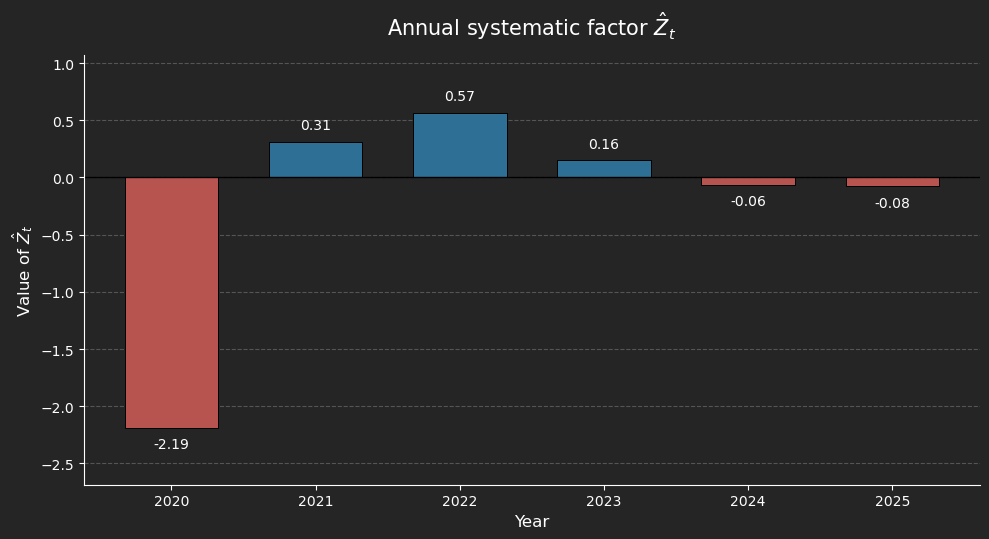

In [48]:
# Grafico a barre dei valori annuali di Z_t

z_annuali = df_Z_results.copy()
z_annuali['Anno'] = z_annuali['Anno'].astype(str)

colori = np.where(z_annuali['Z_t'] >= 0, '#2E6F95', '#B85450')

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.bar(
    z_annuali['Anno'],
    z_annuali['Z_t'],
    color=colori,
    edgecolor='black',
    linewidth=0.7,
    width=0.65
)

ax.axhline(0, color='black', linewidth=1)
ax.set_title(r'Annual systematic factor $\hat{Z}_t$', fontsize=15, pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel(r'Value of $\hat{Z}_t$', fontsize=12)

ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Etichette numeriche sulle barre
for bar, valore in zip(bars, z_annuali['Z_t']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        valore + (0.08 if valore >= 0 else -0.08),
        f'{valore:.2f}',
        ha='center',
        va='bottom' if valore >= 0 else 'top',
        fontsize=10
    )

ax.set_ylim(
    min(z_annuali['Z_t'].min() - 0.5, -0.5),
    max(z_annuali['Z_t'].max() + 0.5, 0.5)
)

plt.tight_layout()
plt.show()

The latent variable Z, by design, follows a mean-reverting stochastic process, meaning a process that naturally tends to return to its long-term average value, which is zero by construction. This property accurately reflects the nature of the credit cycle: favorable conditions like those of 2020-2021, or unfavorable ones like those of the following two years, tend not to persist over time, but rather gradually return to normal.

There are several applications of this model. First of all, it’s possible to simulate macroeconomic shocks that occurred in the past. For example, you can simulate the performance of a credit portfolio under conditions similar to 2008-09 by setting Z values for the first year equal to those of 2008, and for the second year equal to those of 2009. This way, it’s possible to determine the portfolio’s performance under particularly adverse macroeconomic conditions.
Secondly, it is possible to implement a first-order autoregressive model, assuming a significant shock to the variable $Z_t$ and trying to predict the subsequent values of the variable Z and the associated transition matrices.

---

## Linear Regression on Z Values

The factor $Z_t$ estimated in this way basically represents a latent variable, that is, a parameter that is not directly observable but summarizes the effect of the economic cycle. This feature is a structural limitation of the model, since the guidelines of the Basel agreements and international accounting standards (IFRS 9) require adopting a point-in-time and forward-looking approach. This setup requires incorporating forecasts of specific macroeconomic variables into the transition matrices.

For this reason, it was decided to model the latent variable $Z$ through a linear regression on a set of real macroeconomic indicators.

To assess the sensitivity of the systematic factor $Z_t$ to real economic dynamics, two OLS linear regressions were implemented, separately considering the change in the unemployment rate ($Delta UNRATE$) and and GDP growth:
$$z_t = \alpha_{UN} + \beta_{UN} \cdot \Delta \text{Unrate}_t + \varepsilon_t$$

$$z_t = \alpha_{GDP} + \beta_{GDP} \cdot GDP_t + \varepsilon_t$$

To get more data to use for linear regression, the same procedure as before was applied to find the values of $Z$ and $\rho$, but on a quarterly basis instead of an annual one.

In [51]:
df['Trimestre'] = df['Date'].dt.to_period('Q').astype('str')

matrici_trimestrali = {}
trimestri = sorted(df['Trimestre'].unique())

for trimestre in trimestri:
    df_trimestre = df[df['Trimestre'] == trimestre]

    P = pd.crosstab(df_trimestre['STATE'], df_trimestre['Next State'])
    P = P.reindex(index=stati_tot, columns=stati_tot, fill_value=0)
    P = laplace(P)

    P.loc[['PRE', 'DEF'], :] = 0.0
    P.loc['PRE', 'PRE'] = 1
    P.loc['DEF', 'DEF'] = 1

    matrici_trimestrali[trimestre] = P

In [52]:
# funzione obiettivo
def errore_anno(Z_t, rho, P_osservato, soglie):
    P_teorica = P_condizionata(Z_t, soglie, rho)
    P_teorica = P_teorica.loc[P_osservato.index, P_osservato.columns]
    errore = np.sum((P_teorica.values - P_osservato.values) ** 2)
    return errore

def compute_Z_series(rho, matrici_trimestrali, soglie):
    Z_series = []
    for matrice in matrici_trimestrali:
        res = minimize(
            errore_anno, 
            x0=[0.0], 
            bounds=[(-3, 3)], 
            args=(rho, matrice, soglie), 
            method='L-BFGS-B'
        )

        Z_series.append(res.x[0])
    return Z_series


# calibrazione rho
matrici_list = list(matrici_trimestrali.values())

rho_griglia = np.linspace(0.001, 0.1, 100)
results = []
for rho in rho_griglia:
    z_series = compute_Z_series(rho, matrici_list, soglie)
    var_z = np.var(z_series, ddof=1)

    results.append({
        'rho': rho,
        'var_z': var_z,
        'Distanza da 1': abs(var_z - 1),
        'Z_series': z_series
    })

df_results = pd.DataFrame(results)

optimal = df_results.loc[df_results['Distanza da 1'].idxmin()]

df_Z_results = pd.DataFrame({
    'Trimestre': trimestri,
    'Z_t': optimal['Z_series']
})

print("--- Calibration Complete ---")
print(f"Optimal rho: {optimal['rho']:.4f}")
print(f"Z_t Variance: {optimal['var_z']:.4f}")
print("\n Z_t Series:")
df_Z_results.tail(5)

--- Calibration Complete ---
Optimal rho: 0.0870
Z_t Variance: 1.0010

 Z_t Series:


,Trimestre,Z_t
18,2024Q3,-0.146103
19,2024Q4,-0.238326
20,2025Q1,0.132425
21,2025Q2,-0.176406
22,2025Q3,-0.159273


In [53]:
start_date = '2019-12-01'
end_date = '2025-09-30'

macro_data = pdr.DataReader(['UNRATE', 'GDP'], 'fred', start_date, end_date)


macro_q = macro_data.resample('Q').mean()
macro_q['Delta_UNRATE'] = macro_q['UNRATE'].diff()
macro_q['GDP_Growth'] = np.log(macro_q['GDP'] / macro_q['GDP'].shift(1)) * 100
macro_q['Trimestre'] = macro_q.index.to_period('Q').astype(str)

df_regress = pd.merge(df_Z_results, macro_q[['Trimestre', 'Delta_UNRATE', 'GDP_Growth']].dropna(), on='Trimestre', how='inner')


df_regress.tail(10)

,Trimestre,Z_t,Delta_UNRATE,GDP_Growth
12,2023Q2,0.352990,0.000000e+00,1.068534
13,2023Q3,0.015015,1.000000e-01,1.906988
14,2023Q4,0.039861,1.666667e-01,1.416212
15,2024Q1,0.379521,3.333333e-02,1.148805
16,2024Q2,-0.055660,1.333333e-01,1.515804
17,2024Q3,-0.146103,2.000000e-01,1.140438
18,2024Q4,-0.238326,-3.333333e-02,1.214500
19,2025Q1,0.132425,8.881784e-16,0.806729
20,2025Q2,-0.176406,6.666667e-02,1.507196
21,2025Q3,-0.159273,1.333333e-01,1.780707


--Model settings--
Beta unemployment: -0.220
Alpha unemployment: -0.035

Beta GDP : 0.169
Alpha GDP-0.317


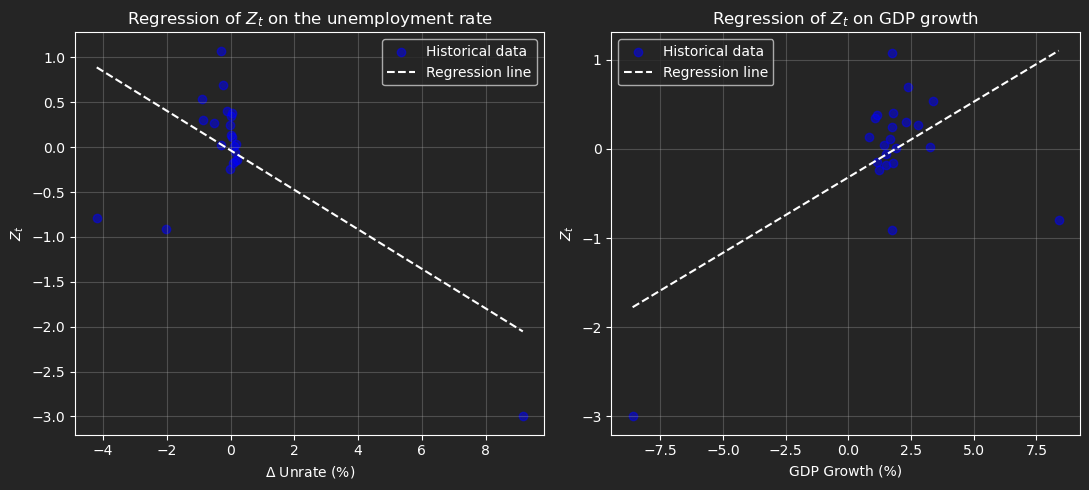

In [55]:
from sklearn.linear_model import LinearRegression

# regressione unrate
un = df_regress[['Delta_UNRATE']].values
z = df_regress['Z_t'].values

model_un = LinearRegression().fit(un, z)
beta_un = model_un.coef_[0]  
alpha_un = model_un.intercept_

# regressione gdp
gdp = df_regress[['GDP_Growth']].values
model_gdp = LinearRegression().fit(gdp, z)
beta_gdp = model_gdp.coef_[0]  
alpha_gdp = model_gdp.intercept_

print("--Model settings--")
print(f"Beta unemployment: {beta_un:.3f}")
print(f"Alpha unemployment: {alpha_un:.3f}")

print(f"\nBeta GDP : {beta_gdp:.3f}")
print(f"Alpha GDP{alpha_gdp:.3f}")

# plot
x_un = np.linspace(un.min(), un.max(), 200)
x_gdp = np.linspace(gdp.min(), gdp.max(), 200)


y_un_pred = alpha_un + beta_un * x_un
y_gdp_pred = alpha_gdp + beta_gdp * x_gdp


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))


ax1.scatter(df_regress['Delta_UNRATE'], df_regress['Z_t'], color='blue', alpha=0.5, label='Historical data')
ax1.plot(x_un, y_un_pred, color='white', linestyle='--', label='Regression line')
ax1.set_title("Regression of $Z_t$ on the unemployment rate")
ax1.set_xlabel('$\Delta$ Unrate (%)')
ax1.set_ylabel('$Z_t$')
ax1.legend()
ax1.grid(True, alpha=0.3)


ax2.scatter(df_regress['GDP_Growth'], df_regress['Z_t'], color='blue', alpha=0.5, label='Historical data')
ax2.plot(x_gdp, y_gdp_pred, color='white', linestyle='--', label='Regression line')
ax2.set_title("Regression of $Z_t$ on GDP growth") 
ax2.set_xlabel('GDP Growth (%)')
ax2.set_ylabel('$Z_t$')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Through linear regression, we were able to link the latent factor Z with explicit macroeconomic variables. This allows you to stress test your loan portfolio, entering possible values of $\Theta \in \{GDP, UNEMPLOYMENT\}$ and observing the different transition probabilities.

---


## Conclusions 

In this project, a discrete-time Markov Chain (DTMC) model was implemented and analyzed using a dataset of over 7.6 million monthly observations related to 200,000 mortgages (2020–2025).

1. **Estimation and Regularization:** The transition matrix was estimated using Maximum Likelihood and regularized with Laplace smoothing ($alpha=1$), ensuring the stability of transition probabilities and avoiding zero probabilities for rare events.
2. **Asymptotic Properties:** Using the canonical form and the Fundamental Matrix $N = (I - Q)^{-1}$, whose spectral radius $rho(Q) < 1$ guarantees convergence, the average times spent in transient states and absorption probabilities $B = NR$ were calculated. The results show that most positions converge to the *Prepayment* (`PRE`) state, while the probability of default (*Lifetime PD*) increases gradually with the worsening of the initial delinquency status (`D30`, `D60`, `D90`). 
3. **Overcoming Temporal Homogeneity:** To get past the limitation of assuming temporal homogeneity (constant matrix over time), the model was conditioned on the economic cycle by calibrating the macroeconomic systematic factor $Z_t$, in line with the Basel III/IV stress-testing guidelines.

---

*This work implements and extends methodologies proposed in the relevant academic literature cited throughout the notebook.*


© 2026 [Riccardo Cordeschi]. All rights reserved.